# Inspect a packaged SweepStim NWB file

Companion to `inspect_packaged_nwb.ipynb`, but for the **passive SweepStim** path
(`sweepstim_packaging/`). It loads one packaged session and plots every piece of
data the packager writes, so you can eyeball that each table/signal is present and
looks physically sensible.

A SweepStim NWB is simpler than a change-detection one — there are no behavioral
trials, licks, or rewards. What it *does* contain, and what this notebook validates:

1. **Session / subject metadata** and **HED schema** version.
2. **`stimulus_presentations`** — one row per movie frame (movie_name,
   movie_frame_index, movie_repeat, stim_block, start/stop_frame, start/stop_time, HED).
3. **`intervals`** — the flat table: session **epochs** (movie blocks +
   `spontaneous` gaps) plus every `stimulus_presentation` row, with a foreign key
   back into `stimulus_presentations`.
4. **Running speed** — processed `speed` + raw encoder traces (`dx`, `v_sig`, `v_in`).
5. **Timing sanity** — frame durations, inter-frame intervals, frame-index ramps,
   and the `start_time` vs `start_frame` alignment (monitor-delay / ~60 Hz vsync).
6. **Cross-table consistency** — the `intervals` foreign keys really line up with
   `stimulus_presentations`, times are monotonic, and nothing has `stop <= start`.
7. **Sidecar** `.events.json`.

Set `SID` in the loader cell to inspect a different session.

In [22]:
# Install required packages if missing. Safe to re-run; pip is a no-op when already installed.
# %pip install --quiet pynwb ndx-events ndx-hed h5py

In [23]:
import warnings
warnings.filterwarnings('ignore')

import json
import pickle
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display

In [24]:
from pynwb import NWBHDF5IO
import ndx_events   # noqa: F401 - registers NdxEventsNWBFile namespace
import ndx_hed      # noqa: F401 - registers HedTags / HedLabMetaData

# This notebook lives in code/sweepstim_packaging/; put the code dir on the path
# so `run_capsule` and the `sweepstim_packaging` package import cleanly.
CODE_DIR = Path.cwd()
if CODE_DIR.name == 'sweepstim_packaging':
    CODE_DIR = CODE_DIR.parent
sys.path.insert(0, str(CODE_DIR.resolve()))

from run_capsule import discover_sessions, find_sync, classify_session  # noqa: E402
from sweepstim_packaging import package_sweepstim_to_nwb                 # noqa: E402

## Load a packaged session

We package on demand so the notebook is self-contained. `KNOWN` lists a couple of
passive-SweepStim sessions already identified in `/data` (a small **drifting-gratings**
session and a large **natural-movie** session with 56 blocks). Pick one with `SID`,
or set `SID = None` to scan `/data` for the first SweepStim session it finds.

The NWB is written to `/results/<sid>.nwb` and reused on re-runs.

In [25]:
DATA_DIR = Path('/data')
RESULTS_DIR = Path('/results')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Known passive-SweepStim sessions (sid -> (stim_pkl, sync_h5)).
KNOWN = {
    # drifting gratings, 2 stimulus blocks - small & fast (default)
    '1414269789': (
        '/data/multiplane-ophys_755252_2025-01-13_09-33-41/behavior/1414269789.pkl',
        '/data/multiplane-ophys_755252_2025-01-13_09-33-41/behavior/1414269789_20250113T093325.h5',
    ),
    # natural movies, 56 stimulus blocks - large, richer frame structure
    '1412914743': (
        '/data/multiplane-ophys_755252_2025-01-03_12-36-54/behavior/1412914743_stim.pkl',
        '/data/multiplane-ophys_755252_2025-01-03_12-36-54/behavior/1412914743_sync.h5',
    ),
}

SID = '1414269789'   # -> set to another key above, or None to auto-discover


def resolve_session(sid):
    """Return (sid, pkl_path, sync_path) for a SweepStim session."""
    if sid in KNOWN:
        pkl, sync = KNOWN[sid]
        return sid, Path(pkl), Path(sync)
    # Auto-discover: scan /data and classify (slow-ish; loads pkls).
    for cand_sid, pkl in sorted(discover_sessions(DATA_DIR).items()):
        if sid is not None and cand_sid != sid:
            continue
        with open(pkl, 'rb') as f:
            data = pickle.load(f, encoding='latin1')
        kind, _ = classify_session(data)
        del data
        if kind == 'sweepstim':
            return cand_sid, pkl, find_sync(pkl, cand_sid)
    raise RuntimeError(f'No SweepStim session found for SID={sid!r}')


SID, PKL_PATH, SYNC_PATH = resolve_session(SID)
NWB_PATH = RESULTS_DIR / f'{SID}.nwb'
if not NWB_PATH.exists():
    print(f'Packaging {SID} -> {NWB_PATH} ...')
    package_sweepstim_to_nwb(str(PKL_PATH), str(SYNC_PATH), str(NWB_PATH))
print(f'NWB: {NWB_PATH}  ({NWB_PATH.stat().st_size / 1e6:.1f} MB)')

NWB: /results/1414269789.nwb  (14.3 MB)


In [26]:
io = NWBHDF5IO(str(NWB_PATH), 'r', load_namespaces=True)
nwb = io.read()
print(f'Session description : {nwb.session_description}')
print(f'Session start time  : {nwb.session_start_time}')
print(f'Identifier          : {nwb.identifier}')
s = nwb.subject
print(f'Subject             : {s.subject_id}  species={s.species}  sex={s.sex}')
print(f'HED schema version  : {nwb.lab_meta_data["hed_schema"].hed_schema_version}')

Session description : STAGE_1
Session start time  : 2025-01-13 09:33:47.192000+00:00
Identifier          : 38cc6a1e-db8b-49f6-97fa-0996bf68b734
Subject             : 755252  species=Mus musculus  sex=U
HED schema version  : 8.3.0


## NWB file structure

In [27]:
nwb

Data type,float64
Shape,"(224520,)"
Array size,1.71 MiB
Chunk shape,None
Compression,None
Compression opts,None
Uncompressed size (bytes),1796160
Compressed size (bytes),1796160
Compression ratio,1.0
Data type,float64
Shape,"(224520,)"


In [28]:
def to_df(table, index_name=None):
    """NWB DynamicTable -> DataFrame with a typed index name."""
    df = table.to_dataframe()
    df.index.name = index_name or f'{table.name}_id'
    return df

## Stimulus presentations

One row per movie frame ("sweep"). This is the finest-grained visual table. Columns:
`start_time`/`stop_time` (visual onset/offset in seconds, monitor-delay corrected),
`start_frame`/`stop_frame` (vsync frame indices), `movie_name`, `movie_frame_index`
(index into the clip), `movie_repeat`, `stim_block`, and the `HED` tag.

In [29]:
sp = to_df(nwb.intervals['stimulus_presentations'])
print(f'{len(sp)} presentation rows, {len(sp.columns)} columns')
print(f'columns: {list(sp.columns)}')
print()
print('frames per stim_block:')
print(sp.groupby("stim_block").size().to_string())
print()
print('frames per movie_name (top 10):')
print(sp["movie_name"].value_counts().head(10).to_string())
sp.head()

1093 presentation rows, 10 columns
columns: ['start_time', 'stop_time', 'movie_name', 'movie_frame_index', 'movie_repeat', 'stim_block', 'start_frame', 'stop_frame', 'epoch_name', 'HED']

frames per stim_block:
stim_block
0    546
1    547

frames per movie_name (top 10):
movie_name
drifting_gratings_TF          547
drifting_gratings_contrast    546


,start_time,stop_time,movie_name,movie_frame_index,movie_repeat,stim_block,start_frame,stop_frame,epoch_name,HED
stimulus_presentations_id,,,,,,,,,,
0,21.683686,23.685366,drifting_gratings_contrast,23,0,0,0,120,passive_viewing,"Sensory-event, Visual-presentation, (Movie, La..."
1,24.686206,26.687896,drifting_gratings_contrast,16,0,0,180,300,passive_viewing,"Sensory-event, Visual-presentation, (Movie, La..."
2,27.688736,29.690426,drifting_gratings_contrast,25,0,0,360,480,passive_viewing,"Sensory-event, Visual-presentation, (Movie, La..."
3,30.691276,32.692966,drifting_gratings_contrast,23,1,0,540,660,passive_viewing,"Sensory-event, Visual-presentation, (Movie, La..."
4,33.693806,35.695486,drifting_gratings_contrast,26,0,0,720,840,passive_viewing,"Sensory-event, Visual-presentation, (Movie, La..."


**Plot:** frames per movie clip, and how the blocks tile the session in time.

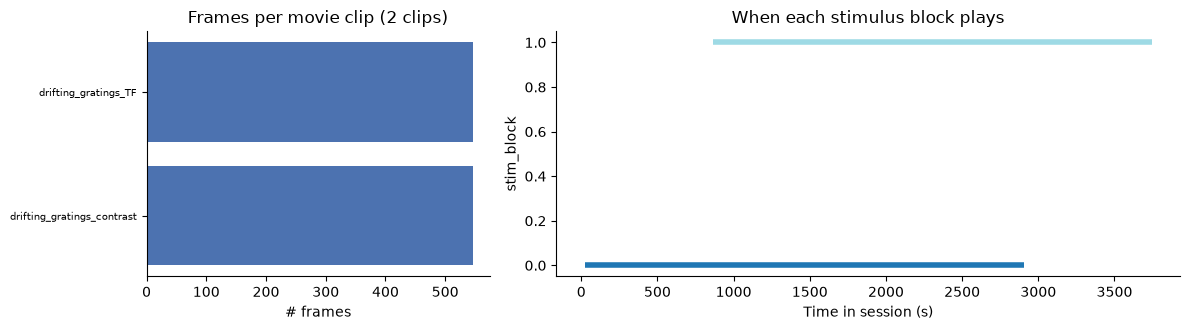

In [30]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 3.4),
                               gridspec_kw={'width_ratios': [1.1, 2.0]})

# Left: frame count per movie clip
counts = sp['movie_name'].value_counts()
show = counts.head(15)
ax0.barh(range(len(show)), show.values, color='#4C72B0')
ax0.set_yticks(range(len(show)))
ax0.set_yticklabels(show.index, fontsize=7)
ax0.invert_yaxis()
ax0.set_xlabel('# frames')
ax0.set_title(f'Frames per movie clip ({len(counts)} clips)')

# Right: session timeline - each block as a horizontal span at its own y
blocks = sorted(sp['stim_block'].unique())
cmap = plt.cm.tab20(np.linspace(0, 1, max(len(blocks), 1)))
for i, b in enumerate(blocks):
    rows = sp[sp['stim_block'] == b]
    ax1.hlines(i, rows['start_time'].min(), rows['stop_time'].max(),
               color=cmap[i % len(cmap)], lw=4)
ax1.set_xlabel('Time in session (s)')
ax1.set_ylabel('stim_block')
ax1.set_title('When each stimulus block plays')
for a in (ax0, ax1):
    for s_ in ('top', 'right'):
        a.spines[s_].set_visible(False)
plt.tight_layout(); plt.show()

## Frame-timing sanity

If the vsync alignment is correct, frame durations and inter-frame intervals should
cluster tightly around a monitor refresh period (~1/60 s = 16.7 ms; movie clips may
hold each frame for a small integer number of refreshes). We also confirm
`start_time` is strictly increasing and no frame has `stop_time <= start_time`.

start_time non-decreasing      : True  (0 exact ties)
any stop_time <= start_time    : False
frame duration  (ms): median=2001.70  min=2001.45  max=2035.07
inter-frame gap (ms): median=3002.54  p1=3002.43  p99=6005.08


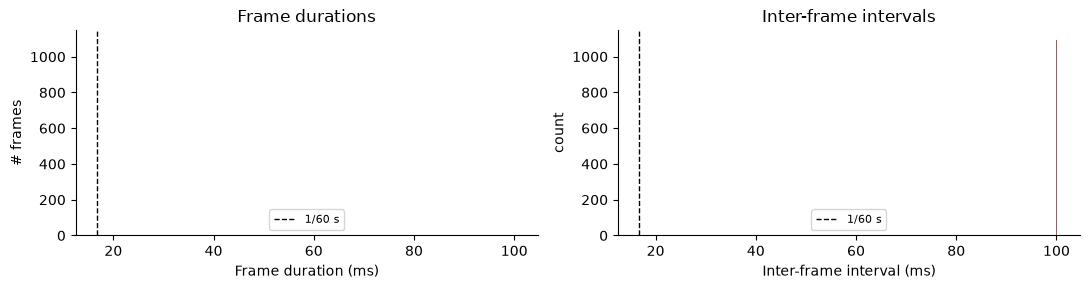

In [31]:
dur = (sp['stop_time'] - sp['start_time']).values
ifi = np.diff(sp['start_time'].values)

print(f'start_time non-decreasing      : {bool(np.all(ifi >= 0))}  '
      f'({int(np.sum(ifi == 0))} exact ties)')
print(f'any stop_time <= start_time    : {bool(np.any(dur <= 0))}')
print(f'frame duration  (ms): median={np.median(dur)*1e3:.2f}  '
      f'min={dur.min()*1e3:.2f}  max={dur.max()*1e3:.2f}')
print(f'inter-frame gap (ms): median={np.median(ifi)*1e3:.2f}  '
      f'p1={np.percentile(ifi,1)*1e3:.2f}  p99={np.percentile(ifi,99)*1e3:.2f}')

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11, 3))
ax0.hist(np.clip(dur*1e3, 0, 100), bins=80, color='#55A868')
ax0.axvline(1000/60, color='k', ls='--', lw=1, label='1/60 s')
ax0.set_xlabel('Frame duration (ms)'); ax0.set_ylabel('# frames')
ax0.set_title('Frame durations'); ax0.legend(fontsize=8)
ax1.hist(np.clip(ifi*1e3, 0, 100), bins=80, color='#C44E52')
ax1.axvline(1000/60, color='k', ls='--', lw=1, label='1/60 s')
ax1.set_xlabel('Inter-frame interval (ms)'); ax1.set_ylabel('count')
ax1.set_title('Inter-frame intervals'); ax1.legend(fontsize=8)
for a in (ax0, ax1):
    for s_ in ('top', 'right'):
        a.spines[s_].set_visible(False)
plt.tight_layout(); plt.show()

**Plot:** `start_time` vs `start_frame` should be almost perfectly linear with a
slope near the vsync period (~16.7 ms/frame) — this is the sync-file timebase the
whole file is built on. And `movie_frame_index` over time (for the busiest block)
should show the clip's frame order sweeping and repeating.

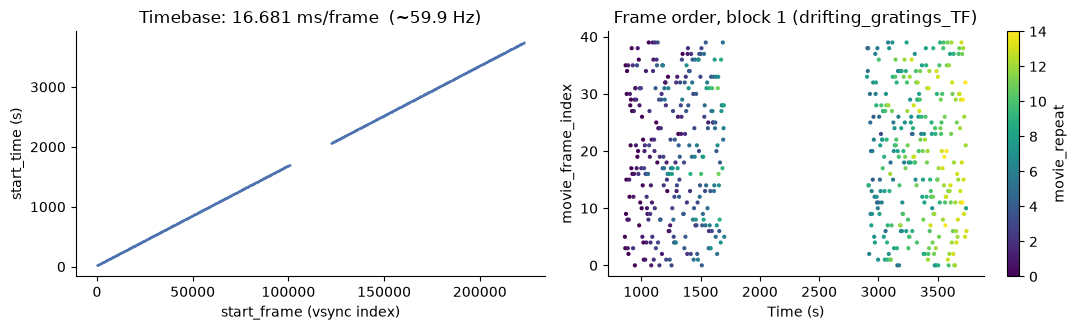

In [32]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11, 3.4))

# start_time vs start_frame: linear -> consistent ~60 Hz timebase
ax0.plot(sp['start_frame'].values, sp['start_time'].values, '.', ms=1, color='#4C72B0')
sl = np.polyfit(sp['start_frame'].values, sp['start_time'].values, 1)[0]
ax0.set_xlabel('start_frame (vsync index)'); ax0.set_ylabel('start_time (s)')
ax0.set_title(f'Timebase: {sl*1e3:.3f} ms/frame  (~{1/sl:.1f} Hz)')

# movie_frame_index over time for the block with the most frames
busiest = sp.groupby('stim_block').size().idxmax()
blk = sp[sp['stim_block'] == busiest]
sc = ax1.scatter(blk['start_time'], blk['movie_frame_index'],
                 c=blk['movie_repeat'], cmap='viridis', s=4)
ax1.set_xlabel('Time (s)'); ax1.set_ylabel('movie_frame_index')
ax1.set_title(f'Frame order, block {busiest} ({blk["movie_name"].iloc[0]})')
plt.colorbar(sc, ax=ax1, label='movie_repeat')
for s_ in ('top', 'right'):
    ax0.spines[s_].set_visible(False); ax1.spines[s_].set_visible(False)
plt.tight_layout(); plt.show()

## Intervals (flat table) and epochs

The `intervals` table holds two `interval_type`s: session-level **`epoch`** rows
(one per movie block, plus `spontaneous` rows filling the gaps) and one
**`stimulus_presentation`** row per frame, carrying a `stimulus_presentations_id`
foreign key back into the table above.

In [33]:
intervals = to_df(nwb.intervals['intervals'])
print(f'{len(intervals)} interval rows, {len(intervals.columns)} columns')
print(f'columns: {list(intervals.columns)}')
print()
print('interval_type counts:')
print(intervals['interval_type'].value_counts().to_string())
print()
print('sample HED per interval_type:')
for it in intervals['interval_type'].unique():
    print(f'  {it:22s} {intervals.loc[intervals.interval_type==it, "HED"].iloc[0]}')

epochs = intervals[intervals['interval_type'] == 'epoch'].copy()
epochs[['start_time', 'stop_time', 'label']]

1098 interval rows, 6 columns
columns: ['start_time', 'stop_time', 'interval_type', 'label', 'stimulus_presentations_id', 'HED']

interval_type counts:
interval_type
stimulus_presentation    1093
epoch                       5

sample HED per interval_type:
  epoch                  Experimental-procedure, (Task, Label/passive_viewing), (Movie, Label/drifting_gratings_contrast)
  stimulus_presentation  Sensory-event, Visual-presentation, (Movie, Label/drifting_gratings_contrast)


,start_time,stop_time,label
intervals_id,,,
0,21.683686,862.411136,drifting_gratings_contrast
275,862.411136,1703.122096,drifting_gratings_TF
549,1703.122096,2063.426836,spontaneous
550,2063.426836,2904.137746,drifting_gratings_contrast
823,2904.137746,3744.882086,drifting_gratings_TF


**Plot:** session epochs across the whole recording. Named blocks are colored;
`spontaneous` gaps are grey. This should tile the session start-to-end with no
overlaps and no holes.

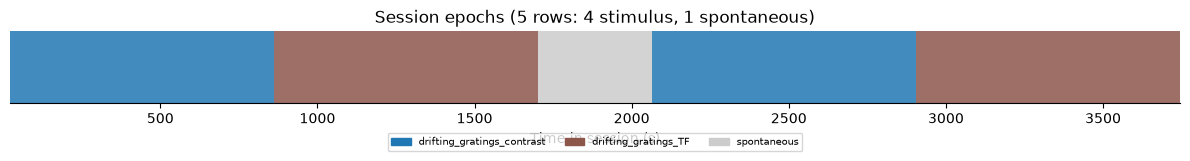

In [34]:
labels = list(dict.fromkeys(epochs['label']))
palette = plt.cm.tab20(np.linspace(0, 1, max(len(labels), 1)))
color_of = {lab: ('#cccccc' if lab == 'spontaneous' else palette[i % len(palette)])
            for i, lab in enumerate(labels)}

fig, ax = plt.subplots(figsize=(12, 2.0))
for _, ep in epochs.iterrows():
    ax.axvspan(ep['start_time'], ep['stop_time'],
               color=color_of[ep['label']], alpha=0.85, lw=0)
ax.set_xlim(float(epochs['start_time'].min()), float(epochs['stop_time'].max()))
ax.set_ylim(0, 1); ax.set_yticks([])
ax.set_xlabel('Time in session (s)')
ax.set_title(f'Session epochs ({len(epochs)} rows: '
             f'{int((epochs.label!="spontaneous").sum())} stimulus, '
             f'{int((epochs.label=="spontaneous").sum())} spontaneous)')
uniq = list(dict.fromkeys(epochs['label']))[:12]
ax.legend(handles=[mpatches.Patch(color=color_of[l], label=l) for l in uniq],
          fontsize=7, ncol=6, loc='upper center', bbox_to_anchor=(0.5, -0.35))
for s_ in ('top', 'right', 'left'):
    ax.spines[s_].set_visible(False)
plt.tight_layout(); plt.show()

**Plot:** a short zoom showing individual `stimulus_presentation` rectangles
inside their epoch, so you can see frames tile continuously within a block.

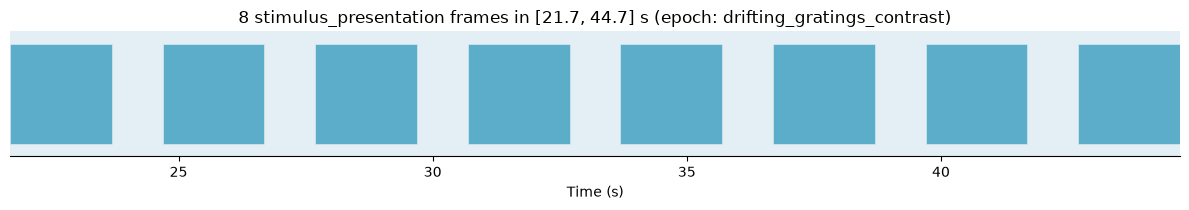

In [35]:
# Zoom in at the first frame of the first stimulus epoch. Size the window so a
# few presentations show regardless of type: movie frames are ~33 ms (window
# stays ~3 s -> many frames), gratings are ~3 s each (window grows to ~8 of them).
stim_ep = epochs[epochs['label'] != 'spontaneous'].iloc[0]
in_ep = sp[(sp['start_time'] >= stim_ep['start_time'] - 1e-6)
           & (sp['start_time'] < stim_ep['stop_time'])]
t0 = float(in_ep['start_time'].iloc[0]) if len(in_ep) else float(stim_ep['start_time'])
first8 = sp[sp['start_time'] >= t0].head(8)
t1 = t0 + max(3.0, float(first8['stop_time'].max() - t0) if len(first8) else 3.0)

fig, ax = plt.subplots(figsize=(12, 2.2))
win = sp[(sp['start_time'] < t1) & (sp['stop_time'] > t0)]
for _, r in win.iterrows():
    ax.add_patch(plt.Rectangle((r['start_time'], 0.1),
                               max(r['stop_time'] - r['start_time'], 1e-4), 0.8,
                               color='#64B5CD', ec='white', lw=0.4))
ax.axvspan(t0, t1, color=color_of.get(stim_ep['label'], '#eee'), alpha=0.12, lw=0)
ax.set_xlim(t0, t1); ax.set_ylim(0, 1); ax.set_yticks([])
ax.set_xlabel('Time (s)')
ax.set_title(f'{len(win)} stimulus_presentation frames in [{t0:.1f}, {t1:.1f}] s '
             f'(epoch: {stim_ep["label"]})')
for s_ in ('top', 'right', 'left'):
    ax.spines[s_].set_visible(False)
plt.tight_layout(); plt.show()

## Running speed

Wheel running speed, computed by the SweepStim running path (rotary-encoder voltage
-> unwrap -> angular change -> linear speed via wheel geometry -> 4 Hz low-pass),
stored as `speed` in `nwb.processing['running']`. Raw `dx` (module) and the encoder
`v_sig` / `v_in` voltages (acquisition) are kept for traceability.

In [36]:
run = nwb.processing['running']
print('running module interfaces:', list(run.data_interfaces.keys()))
print('acquisition           :', list(nwb.acquisition.keys()))

speed_ts = run['speed']
speed = np.asarray(speed_ts.data[:])
speed_t = np.asarray(speed_ts.timestamps[:])
print(f'\nspeed: n={speed.size}, unit={speed_ts.unit}, '
      f't=[{speed_t[0]:.2f}, {speed_t[-1]:.2f}] s')
print(f'  finite={np.isfinite(speed).sum()}/{speed.size}  '
      f'min={np.nanmin(speed):.2f}  median={np.nanmedian(speed):.2f}  '
      f'mean={np.nanmean(speed):.2f}  max={np.nanmax(speed):.2f} cm/s')

running module interfaces: ['dx', 'speed']
acquisition           : ['v_in', 'v_sig']

speed: n=224520, unit=cm/s, t=[21.65, 3766.85] s
  finite=224520/224520  min=-4.65  median=0.12  mean=1.26  max=20.41 cm/s


**Plot:** full-session running speed with epoch backgrounds, plus a speed
histogram. The trace should span the whole session and sit mostly near 0 with
positive-going running bouts.

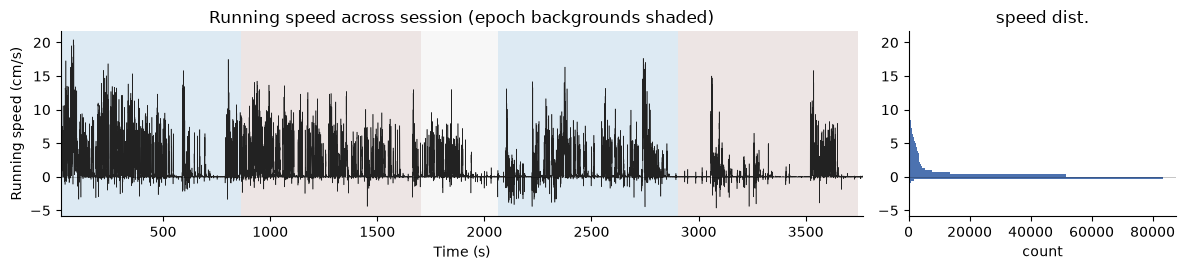

In [37]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 2.8),
                               gridspec_kw={'width_ratios': [3, 1]})
for _, ep in epochs.iterrows():
    ax0.axvspan(ep['start_time'], ep['stop_time'],
                color=color_of[ep['label']], alpha=0.15, lw=0)
ax0.plot(speed_t, speed, color='#222222', lw=0.4)
ax0.axhline(0, color='k', lw=0.4, alpha=0.4)
ax0.set_xlim(speed_t[0], speed_t[-1])
ax0.set_xlabel('Time (s)'); ax0.set_ylabel('Running speed (cm/s)')
ax0.set_title('Running speed across session (epoch backgrounds shaded)')

ax1.hist(speed[np.isfinite(speed)], bins=80, color='#4C72B0', orientation='horizontal')
ax1.axhline(0, color='k', lw=0.4, alpha=0.4)
ax1.set_xlabel('count'); ax1.set_title('speed dist.')
for a in (ax0, ax1):
    for s_ in ('top', 'right'):
        a.spines[s_].set_visible(False)
plt.tight_layout(); plt.show()

**Plot:** raw encoder traces. `v_sig` is the rotary-encoder voltage (sawtooth
that wraps 0->5 V as the wheel turns); `v_in` is the near-constant supply used to
normalize it; `dx` is the raw per-sample angular change.

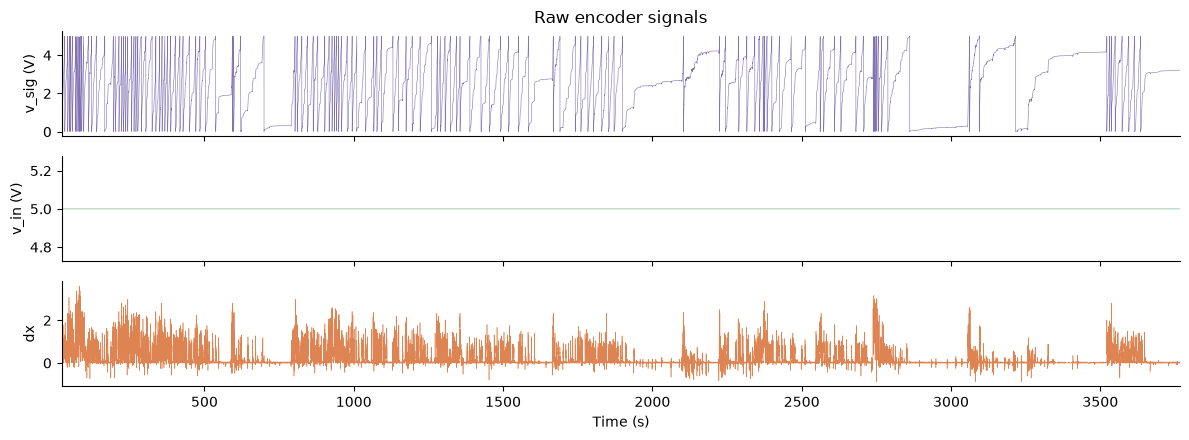

v_sig range: [0.00, 5.00] V
v_in  range: [5.00, 5.00] V
running timestamps vs stimulus span: run [21.6, 3766.8] s vs stim [21.7, 3743.9] s


In [38]:
v_sig = np.asarray(nwb.acquisition['v_sig'].data[:])
v_in = np.asarray(nwb.acquisition['v_in'].data[:])
dx = np.asarray(run['dx'].data[:])
dx_t = np.asarray(run['dx'].timestamps[:])

fig, axes = plt.subplots(3, 1, figsize=(12, 4.5), sharex=True)
axes[0].plot(dx_t, v_sig, color='#8172B3', lw=0.4)
axes[0].set_ylabel('v_sig (V)'); axes[0].set_title('Raw encoder signals')
axes[1].plot(dx_t, v_in, color='#55A868', lw=0.4)
axes[1].set_ylabel('v_in (V)')
axes[2].plot(dx_t, dx, color='#DD8452', lw=0.4)
axes[2].set_ylabel('dx'); axes[2].set_xlabel('Time (s)')
axes[2].set_xlim(dx_t[0], dx_t[-1])
for a in axes:
    for s_ in ('top', 'right'):
        a.spines[s_].set_visible(False)
plt.tight_layout(); plt.show()

print(f'v_sig range: [{np.nanmin(v_sig):.2f}, {np.nanmax(v_sig):.2f}] V')
print(f'v_in  range: [{np.nanmin(v_in):.2f}, {np.nanmax(v_in):.2f}] V')
print(f'running timestamps vs stimulus span: '
      f'run [{dx_t[0]:.1f}, {dx_t[-1]:.1f}] s vs '
      f'stim [{sp["start_time"].min():.1f}, {sp["stop_time"].max():.1f}] s')

**Plot:** running speed zoomed into the same short window used for the interval
zoom, with stimulus-frame boundaries drawn underneath — confirms the running
timebase and the stimulus timebase line up.

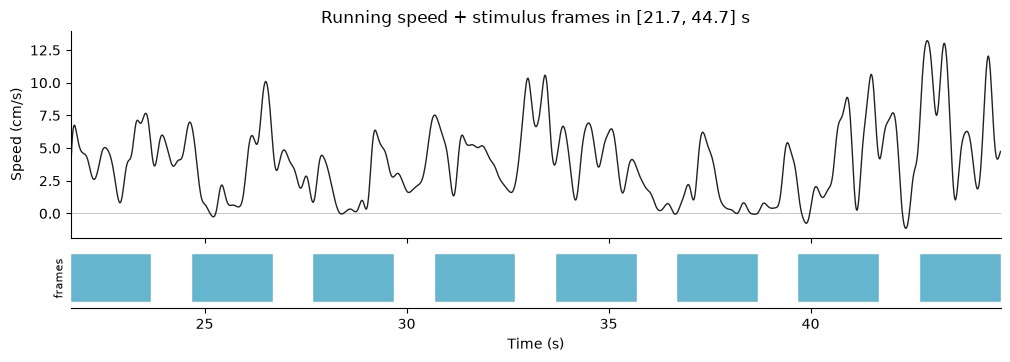

In [39]:
mask = (speed_t >= t0) & (speed_t <= t1)
fig, (ax_s, ax_e) = plt.subplots(2, 1, figsize=(12, 3.6), sharex=True,
                                 gridspec_kw={'height_ratios': [2.4, 0.7], 'hspace': 0.08})
ax_s.plot(speed_t[mask], speed[mask], color='#222222', lw=1.0)
ax_s.axhline(0, color='k', lw=0.4, alpha=0.4)
ax_s.set_ylabel('Speed (cm/s)')
ax_s.set_title(f'Running speed + stimulus frames in [{t0:.1f}, {t1:.1f}] s')
for _, r in win.iterrows():
    ax_e.add_patch(plt.Rectangle((r['start_time'], 0.1),
                                 max(r['stop_time'] - r['start_time'], 1e-4), 0.8,
                                 color='#64B5CD', ec='white', lw=0.3))
ax_e.set_xlim(t0, t1); ax_e.set_ylim(0, 1); ax_e.set_yticks([])
ax_e.set_ylabel('frames', fontsize=8); ax_e.set_xlabel('Time (s)')
for s_ in ('top', 'right'):
    ax_s.spines[s_].set_visible(False)
for s_ in ('top', 'right', 'left'):
    ax_e.spines[s_].set_visible(False)
plt.tight_layout(); plt.show()

## Cross-table consistency checks

The `intervals` table duplicates timing from `stimulus_presentations` and links back
via `stimulus_presentations_id`. These asserts confirm the two tables agree, the
foreign keys resolve, and all times are well-formed. If everything prints ✓ the file
is internally consistent.

In [40]:
checks = []

# 1. Every stimulus_presentation interval row maps 1:1 to a presentation row.
iv_stim = intervals[intervals['interval_type'] == 'stimulus_presentation']
checks.append(('intervals stim rows == stimulus_presentations rows',
               len(iv_stim) == len(sp)))

# 2. Foreign keys cover exactly the stimulus_presentations index.
fk = set(iv_stim['stimulus_presentations_id'].tolist())
checks.append(('FK set == stimulus_presentations index',
               fk == set(sp.index.tolist())))

# 3. Times match between the interval row and the row it points at (sample of 200).
sample = iv_stim.sample(min(200, len(iv_stim)), random_state=0)
ok_times = all(
    np.isclose(r['start_time'], sp.loc[r['stimulus_presentations_id'], 'start_time'])
    and np.isclose(r['stop_time'], sp.loc[r['stimulus_presentations_id'], 'stop_time'])
    for _, r in sample.iterrows())
checks.append(('interval times match referenced presentation (200 sampled)', ok_times))

# 4. Epoch rows carry FK == -1 (no presentation link).
checks.append(('epoch rows have stimulus_presentations_id == -1',
               bool((epochs['stimulus_presentations_id'] == -1).all())))

# 5. Monotonic, well-formed times everywhere.
checks.append(('stimulus_presentations start_time non-decreasing',
               bool(np.all(np.diff(sp['start_time'].values) >= 0))))
checks.append(('no stop_time <= start_time in stimulus_presentations',
               bool(np.all((sp['stop_time'] - sp['start_time']).values > 0))))
checks.append(('epochs tile without gaps/overlap',
               bool(np.allclose(epochs.sort_values('start_time')['start_time'].values[1:],
                                epochs.sort_values('start_time')['stop_time'].values[:-1]))))

# 6. Running speed spans (roughly) the stimulus timeline.
checks.append(('running covers stimulus span',
               dx_t[0] <= sp['start_time'].max() and dx_t[-1] >= sp['start_time'].min()))

# 7. No two presentations overlap in time (blocks may interleave across windows,
#    but individual frames must never play simultaneously).
ss = sp.sort_values('start_time')
checks.append(('no temporal overlap between presentations',
               bool(np.all(ss['start_time'].values[1:]
                           >= ss['stop_time'].values[:-1] - 1e-3))))

# 8. Every presentation falls inside a stimulus epoch of the SAME label -- i.e.
#    frame times and epoch windows are on the same (sync) clock and consistent.
#    This is the check that catches the display_sequence/frame_list misalignment.
stim_ep = epochs[epochs['label'] != 'spontaneous']
samp = sp.sample(min(500, len(sp)), random_state=0)


def _in_matching_epoch(r):
    m = stim_ep[(stim_ep['label'] == r['movie_name'])
                & (stim_ep['start_time'] <= r['start_time'] + 1e-6)
                & (stim_ep['stop_time'] >= r['start_time'] - 1e-6)]
    return len(m) > 0


checks.append(('presentations fall within matching-label epoch (500 sampled)',
               bool(samp.apply(_in_matching_epoch, axis=1).all())))

for name, ok in checks:
    print(f'  {"OK " if ok else "XX "} {name}')
assert all(ok for _, ok in checks), 'One or more consistency checks FAILED'
print('\nAll consistency checks passed.')

  OK  intervals stim rows == stimulus_presentations rows
  OK  FK set == stimulus_presentations index
  OK  interval times match referenced presentation (200 sampled)
  OK  epoch rows have stimulus_presentations_id == -1
  OK  stimulus_presentations start_time non-decreasing
  OK  no stop_time <= start_time in stimulus_presentations
  OK  epochs tile without gaps/overlap
  OK  running covers stimulus span
  OK  no temporal overlap between presentations
  OK  presentations fall within matching-label epoch (500 sampled)

All consistency checks passed.


## Sidecar JSON (`<sid>.events.json`)

The BIDS-style column dictionary written alongside the NWB.

In [41]:
sidecar_path = NWB_PATH.with_suffix('.events.json')
with open(sidecar_path) as f:
    sidecar = json.load(f)
print(f'{sidecar_path}  ({len(sidecar)} keys)')
print(json.dumps(sidecar, indent=2)[:1500])

/results/1414269789.events.json  (12 keys)
{
  "start_time": {
    "Description": "Frame or interval start time (s).",
    "HED": "Time-value/# s"
  },
  "stop_time": {
    "Description": "Frame or interval stop time (s).",
    "HED": "Time-value/# s"
  },
  "movie_name": {
    "Description": "Movie clip label."
  },
  "movie_frame_index": {
    "Description": "Frame index within movie clip.",
    "HED": "Label/movie_frame_index-#"
  },
  "movie_repeat": {
    "Description": "Repeat index within clip.",
    "HED": "Label/movie_repeat-#"
  },
  "stim_block": {
    "Description": "Stimulus block index from pkl top-level stimuli list.",
    "HED": "Label/stim_block-#"
  },
  "start_frame": {
    "Description": "Vsync frame at onset.",
    "HED": "Label/frame-#"
  },
  "stop_frame": {
    "Description": "Vsync frame at offset.",
    "HED": "Label/frame-#"
  },
  "interval_type": {
    "Description": "Type of interval row.",
    "Levels": {
      "epoch": "Session-level epoch row.",
      "

In [42]:
io.close()
print('Done - closed NWB file.')

Done - closed NWB file.
